**Retrival the important features, selecting an important features is very important step before going to ML**

    - Droping the constant features
    - Information gain
    - p-value
    - Forward selection and backward selection
    - Correlation with target column

$Method$ - 1: Variance threshold method

**Droping constanr features**

    - If the feature or variables having sero variance
    - the feature values through out the data is same
    - you can decide manually what is your desired variance in order to keep the feature



**EX- Droping constant feature**

- 1 2 3 4 5 6 : variance
- data dispersion technique: variance
- it will explain about how data is flowing var=0
- it is constant

- variance threshold: 1
- variance threshold === 1 then it is "good variable"
- python will give default variance threshold= 0, but u can make how much u want

In [55]:
import pandas as pd                                                                     # 83 rd class continue
dict1={'A':[100,200,300,400],
       'B':[1,2,3,4],
       'C':[10,20,30,40],
       'D':[10,10,10,10]}
df=pd.DataFrame(dict1)
df

,A,B,C,D
0,100,1,10,10
1,200,2,20,10
2,300,3,30,10
3,400,4,40,10


In [6]:
from sklearn.feature_selection import VarianceThreshold
vt=VarianceThreshold(threshold=0)
vt.fit(df)

,threshold,0


In [7]:
df



,A,B,C,D
0,100,1,10,10
1,200,2,20,10
2,300,3,30,10
3,400,4,40,10


In [9]:
vt.get_support()

# True : the variance not equal to zero
# False: the variance is equal to zero

array([ True,  True,  True, False])

In [10]:
df.columns

Index(['A', 'B', 'C', 'D'], dtype='object')

if the values are constant and if once value is zero we will remove that row or column
- you want to drop the columns: if that columns is useless
- the data is not changing much: variance is zero

In [11]:
vt.get_params()

{'threshold': 0}

In [15]:
cols=df.columns[vt.get_support()]
cols

# D removed becz D == False

Index(['A', 'B', 'C'], dtype='object')

In [16]:
support=vt.get_support()
for i in range(len(support)):
    if support[i]==True:
        print(df.columns[i])

A
B
C


In [17]:
df

,A,B,C,D
0,100,1,10,10
1,200,2,20,10
2,300,3,30,10
3,400,4,40,10


In [18]:
df[cols]

,A,B,C
0,100,1,10
1,200,2,20
2,300,3,30
3,400,4,40


$Method-1$:

In [34]:
# Assignment

# Task : implement the same task on wine data

import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df=pd.read_csv("C:\\Users\\SIDDESH R M\\Downloads\\winequality-red.csv",sep=';')
df


from sklearn.feature_selection import VarianceThreshold
vt=VarianceThreshold(threshold=0.5)     # for 0= all columns will come,  for 0.5= 6 columns and for 1= 5 columns come
vt.fit(df)

cols=df.columns[vt.get_support()]
cols

df[cols]

,fixed acidity,residual sugar,free sulfur dioxide,total sulfur dioxide,alcohol,quality
0,7.4,1.9,11.0,34.0,9.4,5
1,7.8,2.6,25.0,67.0,9.8,5
2,7.8,2.3,15.0,54.0,9.8,5
3,11.2,1.9,17.0,60.0,9.8,6
4,7.4,1.9,11.0,34.0,9.4,5
...,...,...,...,...,...,...
1594,6.2,2.0,32.0,44.0,10.5,5
1595,5.9,2.2,39.0,51.0,11.2,6
1596,6.3,2.3,29.0,40.0,11.0,6
1597,5.9,2.0,32.0,44.0,10.2,5


$Method-2$:

**Information gain**

mutual info classify

- it is value estimating how much relationship/how much information about target variable
- 27% information about target variable
- 0 mean both variables are independent

In [36]:
import pandas as pd

# Read the data
data=pd.read_csv("C:\\Users\\SIDDESH R M\\Downloads\\winequality-red.csv",sep=';')

#Seperate input and target features
X=data.drop('quality',axis=1) # X is dataframe
y=data['quality'] # y is series type

In [ ]:
# mutual info classify

# relation between input vs output (required) ===> Mutual info classify
# relation between input vs output (not required) ===> Multicolinearity avoid

In [37]:
data.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [38]:
# data[['fixed acidity', 'volatile acidity']]
# YY=data['quality']
# YY

In [40]:
from sklearn.feature_selection import mutual_info_classif
MI=mutual_info_classif(X,y)
MI

array([0.03947427, 0.10769705, 0.06234379, 0.03023222, 0.03467189,
       0.04230087, 0.07950862, 0.10003368, 0.03566387, 0.10600241,
       0.1767623 ])

In [41]:
len(MI)

11

In [44]:
val=pd.Series(MI)
val

# I wat replace index with column names

0     0.039474
1     0.107697
2     0.062344
3     0.030232
4     0.034672
5     0.042301
6     0.079509
7     0.100034
8     0.035664
9     0.106002
10    0.176762
dtype: float64

In [48]:
y

0       5
1       5
2       5
3       6
4       5
       ..
1594    5
1595    6
1596    6
1597    5
1598    6
Name: quality, Length: 1599, dtype: int64

In [49]:
MI

array([0.03947427, 0.10769705, 0.06234379, 0.03023222, 0.03467189,
       0.04230087, 0.07950862, 0.10003368, 0.03566387, 0.10600241,
       0.1767623 ])

In [45]:
MI

array([0.03947427, 0.10769705, 0.06234379, 0.03023222, 0.03467189,
       0.04230087, 0.07950862, 0.10003368, 0.03566387, 0.10600241,
       0.1767623 ])

In [52]:
# Two methods almost enough
# Constant features ====  you need to remove
# Mutual information
val=pd.Series(MI)  # index with series
val.index=X.columns   # column with series
val

fixed acidity           0.039474
volatile acidity        0.107697
citric acid             0.062344
residual sugar          0.030232
chlorides               0.034672
free sulfur dioxide     0.042301
total sulfur dioxide    0.079509
density                 0.100034
pH                      0.035664
sulphates               0.106002
alcohol                 0.176762
dtype: float64

In [54]:
val.sort_values(ascending=True)

# What is meant by pH=0.0000?
# what is these all values?

# pH and target columnsare independent each other

residual sugar          0.030232
chlorides               0.034672
pH                      0.035664
fixed acidity           0.039474
free sulfur dioxide     0.042301
citric acid             0.062344
total sulfur dioxide    0.079509
density                 0.100034
sulphates               0.106002
volatile acidity        0.107697
alcohol                 0.176762
dtype: float64

<Axes: >

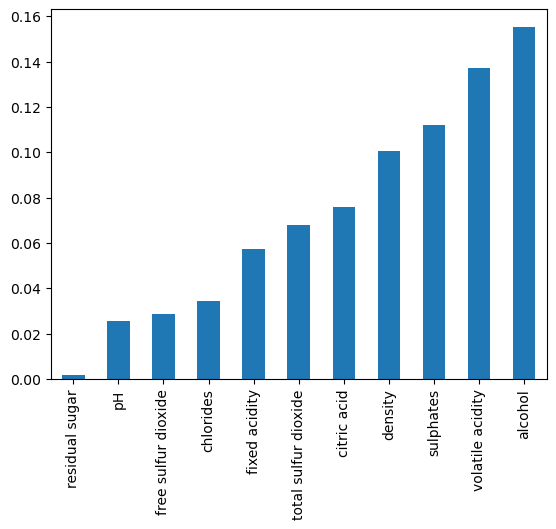

In [59]:
val.sort_values(ascending=True).plot(kind='bar')                                   ######## """84 th class"""

is this suitable for both classification and regression sir mutual info

at which step will do these feature selection

why we are splitting: x and y

python code will allow X and y seperately

thats why we are splitting

ones we extract the important features, those features used to develop a model

[0.0571741  0.13724479 0.07575476 0.00176769 0.03459417 0.02850276
 0.06801184 0.10036552 0.02538141 0.11224308 0.15531832]
0     0.057174
1     0.137245
2     0.075755
3     0.001768
4     0.034594
5     0.028503
6     0.068012
7     0.100366
8     0.025381
9     0.112243
10    0.155318
dtype: float64
fixed acidity           0.057174
volatile acidity        0.137245
citric acid             0.075755
residual sugar          0.001768
chlorides               0.034594
free sulfur dioxide     0.028503
total sulfur dioxide    0.068012
density                 0.100366
pH                      0.025381
sulphates               0.112243
alcohol                 0.155318
dtype: float64


<Axes: >

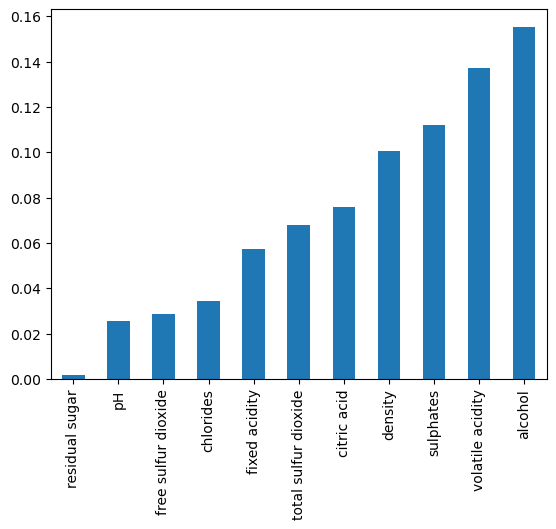

In [58]:
###################### All steps together #####################

import pandas as pd

# Read the data
data=pd.read_csv("C:\\Users\\SIDDESH R M\\Downloads\\winequality-red.csv",sep=';')

#Seperate input and target features
X=data.drop('quality',axis=1) # X is dataframe
y=data['quality'] # y is series type

from sklearn.feature_selection import mutual_info_classif
MI=mutual_info_classif(X,y)
print(MI)

val=pd.Series(MI)  # index with series
print(val)
val.index=X.columns   # column with series
val

val.sort_values(ascending=True)

print(val)

val.sort_values(ascending=True).plot(kind='bar')

**Feature selection methods**                                    

1] Variance selection method

- based on variance we can decide the data is constant or variying

2] p-value     H0: There is no relation between x and y

               H1: There is relation between x and y
  
   p<0.05      Reject the Null hypothesis

3] Mutual info classify : KNN and entropy

- It will give the relation between input and output
- will pick which are having more relation

input vs output

1. Entropy
2. KNN
3. R-square: explainability about y based on x

4] Forward selection and backward selection

   TV  NP  SM Sales
   
   sales = b0+b1*TV  ====> Rsquare

   sales = b0+b1*TV+b2*SM ====> Rsquare    

   sales = b0+b1*TV+b2*SM+b3*NP ====> adding variables to the equation called Forward selection
   
   sales = b0+b1*TV+b2*SM ====> by going equation down decreasing variables in the equation called Backward selection

   sales = b0+b1*TV


$SelectKbest$

**SelectKbest**
  
- means in mutual info it will give that relation ship between input and output 
- Ex:- number of input columns are 11
    - it will give 11 vaues, then you will do pd.series(11), the convert index==column === then sort === will select top 5
 
- seleck K best means , if we give k=5, then it will give top 5 columns.it will avoid manuall things


In [66]:
import pandas as pd

# read the data
data=pd.read_csv("C:\\Users\\SIDDESH R M\\Downloads\\winequality-red.csv",sep=';')

# Seperate input and target features
X=data.drop('quality',axis=1)
y=data['quality']

# assume that you did not done mutual info classii
from sklearn.feature_selection import SelectKBest,mutual_info_classif
top_5=SelectKBest(mutual_info_classif,k=5)
val=top_5.fit(X,y)


In [68]:
dir(val)

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_build_request_for_signature',
 '_check_params',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_params_html',
 '_get_support_mask',
 '_html_repr',
 '_parameter_constraints',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_sklearn_auto_wrap_output_keys',
 '_transform',
 '_validate_params',
 'feature_name

In [69]:
val.get_support()

array([False,  True, False, False, False, False,  True,  True, False,
        True,  True])

In [70]:
val.get_feature_names_out()  # Which is True

array(['volatile acidity', 'total sulfur dioxide', 'density', 'sulphates',
       'alcohol'], dtype=object)

In [72]:
val.get_params()   # What ever you pass inside package

{'k': 5,
 'score_func': <function sklearn.feature_selection._mutual_info.mutual_info_classif(X, y, *, discrete_features='auto', n_neighbors=3, copy=True, random_state=None, n_jobs=None)>}

In [74]:
val.scores_

array([0.0555249 , 0.11520512, 0.06123226, 0.01417481, 0.04087358,
       0.00713044, 0.0660222 , 0.08644788, 0.02090042, 0.09700901,
       0.1882119 ])

**Assignment**

In [44]:
# step-1:
import numpy as np                                        
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


# step-2:

data=pd.read_csv("C:\\DS_Py\\ML Python\\telco_churn.csv")
data.head()
# data.shape
# data.info()
# data.isnull().sum()

data[['MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'TotalCharges', 'Churn']].isnull().sum()        # here we selected missing columns and checking

col1=data['PhoneService']
col2=data['MultipleLines']
result=pd.crosstab(col1,col2,dropna=False)                      
result

data['MultipleLines']=data['MultipleLines'].fillna('No phone servce')
data['MultipleLines'].isnull().sum()


# We need to find out why all six columns have exactly 651 missing values.
pd.crosstab(data['InternetService'], data['OnlineSecurity'], dropna=False)

# We create a list containing the six columns that have the same type of missing value.
# In the current column, replace only the NaN values with No internet service."
internet_cols=['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

for col in internet_cols:
    data[col]=data[col].fillna('No internet Service')

data.isnull().sum()

# checking NaN rows
data[data['TotalCharges'].isnull()]

# Fill TotalCharges
data['TotalCharges'] = data['TotalCharges'].fillna(0)
data['TotalCharges'].isnull().sum()

np.int64(0)

In [ ]:
# step-3
X=data.drop('Churn',axis=1)
# output
y=data['Churn']
